# DFES Station Overtime Forecasting

## Problem Statement

Using DFES overtime, employee and termination data from 2022–2025, this project predicts monthly staffing-driven overtime hours at the station level, and flags stations at highest risk of an overtime spike. Success is measured against a naive baseline (last month's actual value).

This addresses a challenge described in the DFES Workforce Services brief: the reactive nature of rostering significantly increases overtime costs, and there is a clear need for predictive analytics to better anticipate staffing gaps.

## 1. Import

This section contains all necessary imports of libraries and datasets required for the analysis.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression

## 2. Data Loading

In [2]:
overtime_df = pd.read_excel('data/FFC - Overtime Data.xlsx')
overtime_df.head()

,Employee ID,Employee Name,Work From Date,Payment Code,Payment Name,Start Time,End Time,Units,Classification,Level,Classification Description,Cost Centre Code,Cost Centre Description,Incident No.,Overtime Reason Code,Overtime Reason Description,Position No,Position Title
0,111121,"Burns, Rodney A",2022-07-06,ot,Overtime FS EBA,800,920,2.00,feso,2,Station Officer 2,4010,OsbornePark FireStation (4010),NaN,hbis,Hold Back: Cover Insufficient Staff,2050,Station Officer
1,111121,"Burns, Rodney A",2022-08-13,ot,Overtime FS EBA,1800,800,14.00,feso,2,Station Officer 2,4010,OsbornePark FireStation (4010),NaN,hbsl,Hold Back: Cover Sick Leave,2050,Station Officer
2,111121,"Burns, Rodney A",2022-09-16,ot,Overtime FS EBA,800,820,2.00,feso,2,Station Officer 2,4010,OsbornePark FireStation (4010),NaN,hbis,Hold Back: Cover Insufficient Staff,2050,Station Officer
3,111121,"Burns, Rodney A",2022-09-22,ot,Overtime FS EBA,1801,800,13.98,feso,2,Station Officer 2,4024,Vincent Fire Station (4024),NaN,hbis,Hold Back: Cover Insufficient Staff,2050,Station Officer
4,111121,"Burns, Rodney A",2023-01-04,ot,Overtime FS EBA,1800,800,14.00,feso,2,Station Officer 2,4010,OsbornePark FireStation (4010),NaN,hbis,Hold Back: Cover Insufficient Staff,2050,Station Officer


In [3]:
overtime_df.shape

(75315, 18)

- Units are overtime hours paid
- Overtime is paid at a minimum of 2 hours

## 3. Exploratory Data Analysis

### What fire station has the most overtime in hours total?

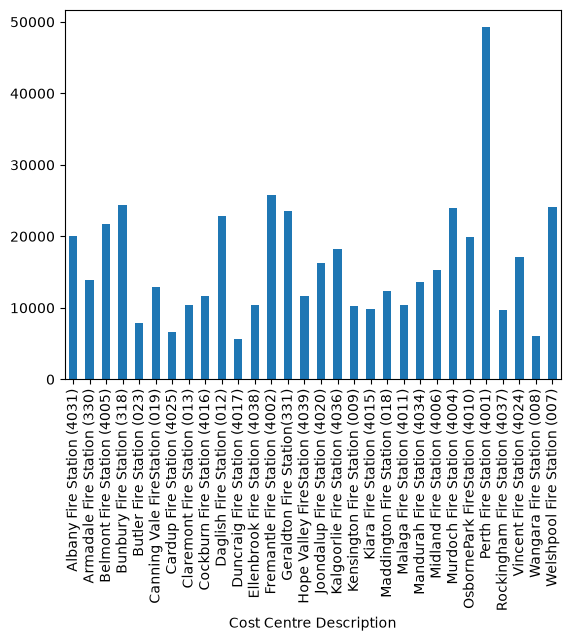

In [4]:
overtime_by_station = overtime_df.groupby('Cost Centre Description')['Units'].sum()

overtime_by_station.plot.bar('Cost Centre Description', 'Units')
plt.show()

### What is the reason for most of the overtime?

In [5]:
overtime_reasons = overtime_df['Overtime Reason Description'].value_counts(ascending=False)
overtime_reasons

Overtime Reason Description
Hold Back: Cover Insufficient Staff                       24338
Hold Back: Cover Sick Leave                               16642
Call Back: Cover Insufficient Staff                       10548
Hold Back: Incident                                       10326
Call Back: Cover Sick Leave                                5022
Hold Back: Cover Workers Compensation Absence              3092
Call Back: Training                                         696
Call Back: Cover Workers Compensation Absence               692
Hold Back: Cover COVID-19 Absence                           681
Training: Operational                                       465
Hold Back: Training                                         454
Hold Back: Cover Special Leave                              412
Wild Fire Suppression                                       400
Overtime During Normal Hours (Third Consecutive Shift)      388
Call Back: Meetings                                         290
Call Back: C

In [6]:
round((24338 + 16642 + 10548 + 5022) / len(overtime_df) * 100, 1)

75.1

**Findings:** 
- Perth Fire Station has the highest number of overtime hours
- Insufficient staffing and sick leave together account for ~75% of all overtime records, confirming the DFES brief's description of overtime as driven by unplanned staffing gaps rather than incidents or training.

### Visualisations for Overtime Reasons

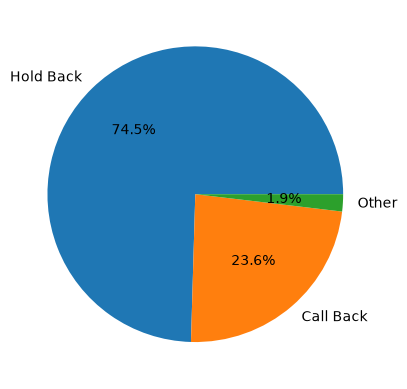

In [7]:
# Hold back  vs call back

def get_mechanism(reason):
    if reason.startswith('Hold Back'):
        return 'Hold Back'
    elif reason.startswith('Call Back'):
        return 'Call Back'
    else:
        return 'Other'

overtime_df['Mechanism'] = overtime_df['Overtime Reason Description'].apply(get_mechanism)

mechanism_counts = overtime_df['Mechanism'].value_counts()

plt.pie(overtime_df['Mechanism'].value_counts(), labels=mechanism_counts.index, autopct='%1.1f%%')
plt.show()

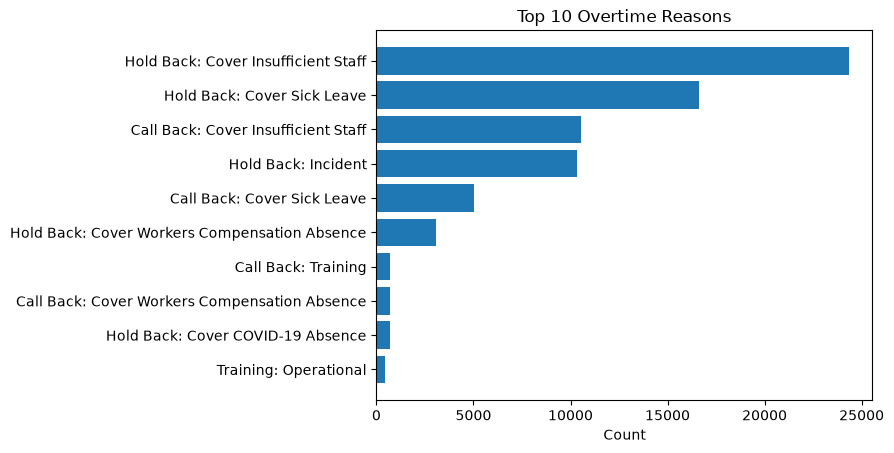

In [8]:
top_10 = overtime_reasons.head(10).sort_values() # ascending

plt.barh(top_10.index, top_10.values)
plt.xlabel("Count")
plt.title("Top 10 Overtime Reasons")
plt.show()

This confirms that cover for insufficient staff and sick leave are the top overtime reasons

### Has overtime gone up or down over time?

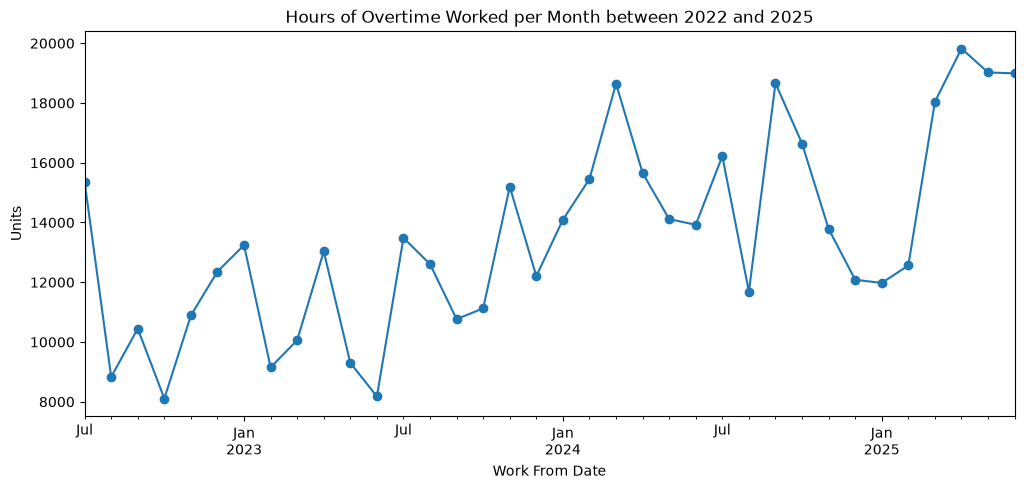

In [9]:
monthly = overtime_df.groupby(overtime_df['Work From Date'].dt.to_period('M'))['Units'].sum()

monthly.plot(marker='o', figsize=(12,5))
plt.ylabel("Units")
plt.title("Hours of Overtime Worked per Month between 2022 and 2025")
plt.show()

**Findings**:
- Appears to be a trend, where hours drop in the middle of the year (winter), and trend upwards during the summer months.
- The overtime hours are increasing overtime.

## 4. Data Joining

In [10]:
employee_df = pd.read_excel('data/FFC - Current CFRS Employee List.xlsx')
employee_df.head()

,Employee ID,Date of Birth,Gender,Date Commenced DFES,Position Number,Position Title,Classification Description,Work Pattern,Command,Portfolio/Directorate,Region (Ops Only),Branch,Section,Location
0,113055,1987-04-11,m,2017-07-19,7107,Firefighter,1st Class Firefighter,c,Operations,Metropolitan Operations,Central Region,Perth District,Vincent Fire Station,Vincent Fire Station
1,113066,1991-10-15,m,2017-10-16,1673,Firefighter,1st Class Firefighter,d,Operations,Metropolitan Operations,North East Region,Swan District,Belmont Fire Station,Belmont Fire Station
2,113259,1992-12-26,f,2019-06-26,1601,Firefighter,1st Class Firefighter,d,Operations,Metropolitan Operations,South Coastal Region,Cockburn Sound District,Cockburn Fire Station,Cockburn Fire Station
3,113366,1992-05-12,m,2020-02-24,1895,Firefighter,1st Class Firefighter,a,Operations,Metropolitan Operations,Central Region,Perth District,Perth Fire Station,Perth Fire Station
4,113368,1982-06-28,m,2020-02-24,1742,Firefighter,1st Class Firefighter,c,Operations,Metropolitan Operations,Central Region,Perth District,Perth Fire Station,Perth Fire Station


In [12]:
merged_df = pd.merge(overtime_df, employee_df, how='left', on='Employee ID')
merged_df.head()

,Employee ID,Employee Name,Work From Date,Payment Code,Payment Name,Start Time,End Time,Units,Classification,Level,...,Position Number,Position Title_y,Classification Description_y,Work Pattern,Command,Portfolio/Directorate,Region (Ops Only),Branch,Section,Location
0,111121,"Burns, Rodney A",2022-07-06,ot,Overtime FS EBA,800,920,2.00,feso,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,111121,"Burns, Rodney A",2022-08-13,ot,Overtime FS EBA,1800,800,14.00,feso,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,111121,"Burns, Rodney A",2022-09-16,ot,Overtime FS EBA,800,820,2.00,feso,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,111121,"Burns, Rodney A",2022-09-22,ot,Overtime FS EBA,1801,800,13.98,feso,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,111121,"Burns, Rodney A",2023-01-04,ot,Overtime FS EBA,1800,800,14.00,feso,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
# How many overtime rows failed to find a matching employee?
print(merged_df['Region (Ops Only)'].isna().sum())

1890


In [14]:
shared = set(overtime_df.columns) & set(employee_df.columns)
print(shared)

{'Position Title', 'Employee ID', 'Classification Description'}


In [15]:
comparison = merged_df[['Employee ID', 'Position Title_x', 'Position Title_y']].dropna()
comparison.head()

,Employee ID,Position Title_x,Position Title_y
40,111127,Station Officer,Station Officer
41,111127,Station Officer,Station Officer
42,111127,Station Officer,Station Officer
43,111127,Station Officer,Station Officer
44,111127,Station Officer,Station Officer


In [16]:
len(merged_df) - len(comparison)

1890

Verify if unmatched Employee IDs is due to terminations (terminated employees who show up in Overtime data won't be in the Current Employee List)

In [17]:
terminations_df = pd.read_excel('data/FFC - Terminations.xlsx')
terminations_df

,Employee ID,Date Commenced Agency,Termination Date,Termination Reason Description (Group),Location Description,Position Number,Position Title
0,111111,1970-09-11,2017-01-19,Retirement (Age),Welshpool Fire Station,1189,Station Officer
1,111112,1973-08-03,2016-03-14,Retirement (Medical),Joondalup Fire Station,1993,Firefighter
2,111114,1973-10-12,2020-05-18,Retirement (Age),Osborne Park Fire Station,1240,Station Officer
3,111116,1973-10-12,2015-12-10,Retirement (Age),Duncraig Fire Station,1267,Station Officer
4,111118,1974-05-31,2020-03-23,Retirement (Age),Bunbury Fire Station,11448,Firefighter
...,...,...,...,...,...,...,...
251,113516,2021-03-02,2021-09-12,Resignation,Perth Fire Station,15062,Firefighter
252,113586,2021-07-27,2022-02-22,Resignation,Murdoch Fire Station,6107,Firefighter
253,113717,2022-02-21,2025-01-31,Resignation,Osborne Park Fire Station,1925,Firefighter
254,113719,2022-02-21,2023-10-06,Resignation,Duncraig Fire Station,1875,Firefighter


In [18]:
terminations_df.shape

(256, 7)

In [19]:
unmatched = merged_df[merged_df['Region (Ops Only)'].isna()]

unmatched_ids = unmatched['Employee ID'].unique()
len(unmatched_ids)

73

In [20]:
# Found in terminations?
found_in_terminations = terminations_df['Employee ID'].isin(unmatched_ids)
found_in_terminations.sum()

np.int64(66)

73 Employee IDs were unmatched in the merged data set, and 66 of these were found in Terminations. 7 are unaccounted for, which will need to be investigated further.

In [21]:
final_df = merged_df.merge(
    terminations_df[['Employee ID', 'Termination Date', 'Termination Reason Description (Group)']],
    how='left',
    on='Employee ID'
)
final_df.head()

,Employee ID,Employee Name,Work From Date,Payment Code,Payment Name,Start Time,End Time,Units,Classification,Level,...,Classification Description_y,Work Pattern,Command,Portfolio/Directorate,Region (Ops Only),Branch,Section,Location,Termination Date,Termination Reason Description (Group)
0,111121,"Burns, Rodney A",2022-07-06,ot,Overtime FS EBA,800,920,2.00,feso,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-31,Retirement (Age)
1,111121,"Burns, Rodney A",2022-08-13,ot,Overtime FS EBA,1800,800,14.00,feso,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-31,Retirement (Age)
2,111121,"Burns, Rodney A",2022-09-16,ot,Overtime FS EBA,800,820,2.00,feso,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-31,Retirement (Age)
3,111121,"Burns, Rodney A",2022-09-22,ot,Overtime FS EBA,1801,800,13.98,feso,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-31,Retirement (Age)
4,111121,"Burns, Rodney A",2023-01-04,ot,Overtime FS EBA,1800,800,14.00,feso,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-31,Retirement (Age)


## 5. Feature Engineering

Create the features for the model:
- Predicted (Native Baseline) - 1 month lag of staff-driven overtime hours
- Rolling Moving Average (last 3 months of staff-driven overtime hours)
- Month of Year
- Station flags (one-hot encoding)

### Target Variable and Naive Baseline

Predicted (Naive) uses the previous months' figure, so we use 'shift'

In [22]:
final_df['Month'] = final_df['Work From Date'].dt.to_period('M')

station_month = final_df.groupby(['Cost Centre Description', 'Month'])['Units'].sum().reset_index()
final_df['Staffing Driven'] = final_df['Overtime Reason Description'].str.contains('Cover Insufficient Staff|Cover Sick Leave')
staffing_only = final_df[final_df['Staffing Driven']]
staffing_month = staffing_only.groupby(['Cost Centre Description', 'Month'])['Units'].sum().reset_index()

station_month = station_month.merge(staffing_month, how='left', on=['Cost Centre Description', 'Month'])
station_month = station_month.rename(columns={'Cost Centre Description': 'Station', 
                                              'Units_x': 'Total Overtime Hours', 
                                              'Units_y': 'Staffing Driven Overtime Hours'})
station_month.head()

,Station,Month,Total Overtime Hours,Staffing Driven Overtime Hours
0,Albany Fire Station (4031),2022-07,710.42,445.42
1,Albany Fire Station (4031),2022-08,597.32,519.32
2,Albany Fire Station (4031),2022-09,254.48,243.98
3,Albany Fire Station (4031),2022-10,760.24,602.24
4,Albany Fire Station (4031),2022-11,426.74,328.98


In [23]:
station_month['Predicted (Naive)'] = station_month.groupby('Station')['Staffing Driven Overtime Hours'].shift(1)

station_month = station_month.dropna()
station_month

,Station,Month,Total Overtime Hours,Staffing Driven Overtime Hours,Predicted (Naive)
1,Albany Fire Station (4031),2022-08,597.32,519.32,445.42
2,Albany Fire Station (4031),2022-09,254.48,243.98,519.32
3,Albany Fire Station (4031),2022-10,760.24,602.24,243.98
4,Albany Fire Station (4031),2022-11,426.74,328.98,602.24
5,Albany Fire Station (4031),2022-12,215.61,211.61,328.98
...,...,...,...,...,...
1046,Welshpool Fire Station (007),2025-02,757.40,688.45,544.78
1047,Welshpool Fire Station (007),2025-03,914.01,819.84,688.45
1048,Welshpool Fire Station (007),2025-04,1018.36,968.46,819.84
1049,Welshpool Fire Station (007),2025-05,971.26,950.75,968.46


In [24]:
# MAE
actual_val = station_month['Staffing Driven Overtime Hours']
pred_val = station_month['Predicted (Naive)']
sae = (actual_val - pred_val).abs()
mae = sae.mean()
mae

np.float64(162.36007850834153)

In [25]:
# Verify with sklearn
mean_absolute_error(actual_val, pred_val)

162.36007850834153

In [26]:
station_month['Staffing Driven Overtime Hours'].describe()

count    1019.000000
mean      398.863837
std       302.575005
min        16.000000
25%       193.300000
50%       324.000000
75%       535.055000
max      2147.070000
Name: Staffing Driven Overtime Hours, dtype: float64

In [27]:
mean_actual = station_month['Staffing Driven Overtime Hours'].mean()
print(mean_actual, 162.36 / mean_actual)

398.86383709519134 0.4070562054018745


### Rolling Moving Average

In [28]:
station_month['Rolling Average (3mo)'] = station_month.groupby('Station')['Staffing Driven Overtime Hours'].rolling(3).mean().reset_index(level=0, drop=True)
station_month

,Station,Month,Total Overtime Hours,Staffing Driven Overtime Hours,Predicted (Naive),Rolling Average (3mo)
1,Albany Fire Station (4031),2022-08,597.32,519.32,445.42,NaN
2,Albany Fire Station (4031),2022-09,254.48,243.98,519.32,NaN
3,Albany Fire Station (4031),2022-10,760.24,602.24,243.98,455.180000
4,Albany Fire Station (4031),2022-11,426.74,328.98,602.24,391.733333
5,Albany Fire Station (4031),2022-12,215.61,211.61,328.98,380.943333
...,...,...,...,...,...,...
1046,Welshpool Fire Station (007),2025-02,757.40,688.45,544.78,630.926667
1047,Welshpool Fire Station (007),2025-03,914.01,819.84,688.45,684.356667
1048,Welshpool Fire Station (007),2025-04,1018.36,968.46,819.84,825.583333
1049,Welshpool Fire Station (007),2025-05,971.26,950.75,968.46,913.016667


### Month of Year Indicator

In [29]:
station_month['Month of Year'] = station_month['Month'].dt.month

### Station Flags

In [30]:
station_dummies = pd.get_dummies(station_month['Station'], prefix='Station', drop_first=True)
station_month = pd.concat([station_month, station_dummies], axis=1)

## 6. Modeling

In [31]:
station_month_regression = station_month.copy()
station_month_regression.dropna(inplace=True)

print(station_month_regression['Month'].min(), station_month_regression['Month'].max()) # Test from 2025-03 onwards

2022-10 2025-06


In [32]:
training_mask = station_month_regression['Month'] < '2025-03'

training = station_month_regression[training_mask]
testing = station_month_regression[~training_mask]

In [33]:
X_train = training.iloc[:, 4:]
X_test = testing.iloc[:, 4:]

y_train = training['Staffing Driven Overtime Hours']
y_test = testing['Staffing Driven Overtime Hours']

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](32,)","[-0.51, 1.51,-0.24,...,-8.53,-6.02, 6.48]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](32,)","['Predicted (Naive)','Rolling Average (3mo)','Month of Year',..., 'Station_Vincent Fire Station (4024)', 'Station_Wangara Fire Station (008)', 'Station_Welshpool Fire Station (007)']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.539
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,32
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(31)


In [34]:
y_pred = model.predict(X_test)
mae_2 = mean_absolute_error(y_test, y_pred)
print(mae, mae_2)

162.36007850834153 101.18237077140388


In [35]:
improvement = (mae - mae_2) / mae
print(improvement)
# 38% better than assuming no change, on a target that itself has huge station-to-station and month-to-month variance

0.3768026493889293


In [36]:
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Weight': model.coef_
})
coefficients = coefficients.sort_values('Weight', ascending=False)
coefficients

,Feature,Weight
4,Station_Belmont Fire Station (4005),1.441723e+01
26,Station_OsbornePark FireStation (4010),1.279001e+01
14,Station_Fremantle Fire Station (4002),9.251804e+00
11,Station_Daglish Fire Station (012),8.716329e+00
16,Station_Hope Valley FireStation (4039),7.732669e+00
31,Station_Welshpool Fire Station (007),6.482261e+00
24,Station_Midland Fire Station (4006),5.561598e+00
28,Station_Rockingham Fire Station (4037),4.364676e+00
7,Station_Canning Vale FireStation (019),4.108099e+00
19,Station_Kensington Fire Station (009),3.859804e+00


In [37]:
X_train[['Predicted (Naive)', 'Rolling Average (3mo)']].corr()

,Predicted (Naive),Rolling Average (3mo)
Predicted (Naive),1.000000,0.914173
Rolling Average (3mo),0.914173,1.000000


**Findings:**
- Belmont, Osborne Park & Fremantle are the heaviest weights. Much higher compared to Albany
- Perth has the highest raw overtime of any station, but its model coefficient is -1. Its overtime is fully explained by its own recent trend, not an unexplained "Perth effect"
- Rolling Average is 1.5 vs Predicted (-0.5). Model learns more from smoothed average than one noisy month.
- Month of year is -0.2
- Lag and Rolling Average are highly correlated (r=0.91), so their individual coefficients shouldn't be interpreted as 'which one matters more'. The model's overall predictive performance (MAE=101) remains valid and is what should be trusted, not the individual weight split between these two correlated features.
- Model MAE: 101.18 vs. naive baseline MAE: 162.36 — a ~38% reduction in error.

## 7. Risk Flag

In [38]:
station_thresholds = station_month_regression.groupby('Station')['Staffing Driven Overtime Hours'].quantile(0.8)

results = X_test.copy()
results['Actual'] = y_test.values
results['Predicted'] = y_pred
results['Naive Baseline'] = X_test['Predicted (Naive)'].values
results['Station'] = station_month_regression.loc[X_test.index, 'Station'].values
results['Month'] = station_month_regression.loc[X_test.index, 'Month'].values
results['Threshold'] = results['Station'].map(station_thresholds)
results['Risk Flag'] = results['Predicted'] > results['Threshold']
results[['Station', 'Month', 'Actual', 'Predicted', 'Naive Baseline', 'Threshold', 'Risk Flag']]                                    

,Station,Month,Actual,Predicted,Naive Baseline,Threshold,Risk Flag
32,Albany Fire Station (4031),2025-03,510.31,544.335072,311.58,622.778,False
33,Albany Fire Station (4031),2025-04,529.90,423.022079,510.31,622.778,False
34,Albany Fire Station (4031),2025-05,663.36,589.526566,529.90,622.778,False
35,Albany Fire Station (4031),2025-06,546.24,539.745980,663.36,622.778,False
68,Armadale Fire Station (330),2025-03,984.49,622.872552,597.95,468.000,True
...,...,...,...,...,...,...,...
1014,Wangara Fire Station (008),2025-06,78.08,147.268512,241.50,175.462,False
1047,Welshpool Fire Station (007),2025-03,819.84,691.709138,688.45,807.764,False
1048,Welshpool Fire Station (007),2025-04,968.46,837.703806,819.84,807.764,True
1049,Welshpool Fire Station (007),2025-05,950.75,893.928267,968.46,807.764,True


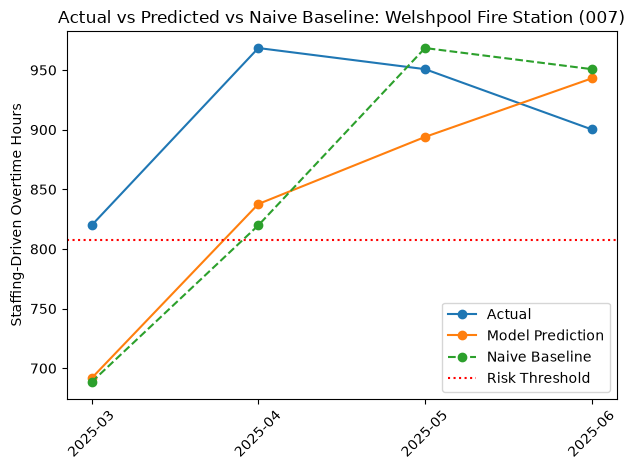

In [39]:
station_to_plot = 'Welshpool Fire Station (007)'
station_data = results[results['Station'] == station_to_plot].sort_values('Month')

plt.plot(station_data['Month'].astype(str), station_data['Actual'], label='Actual', marker='o')
plt.plot(station_data['Month'].astype(str), station_data['Predicted'], label='Model Prediction', marker='o')
plt.plot(station_data['Month'].astype(str), station_data['Naive Baseline'], label='Naive Baseline', marker='o', linestyle='--')
plt.axhline(station_data['Threshold'].iloc[0], color='red', linestyle=':', label='Risk Threshold')
plt.legend()
plt.title(f'Actual vs Predicted vs Naive Baseline: {station_to_plot}')
plt.ylabel('Staffing-Driven Overtime Hours')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

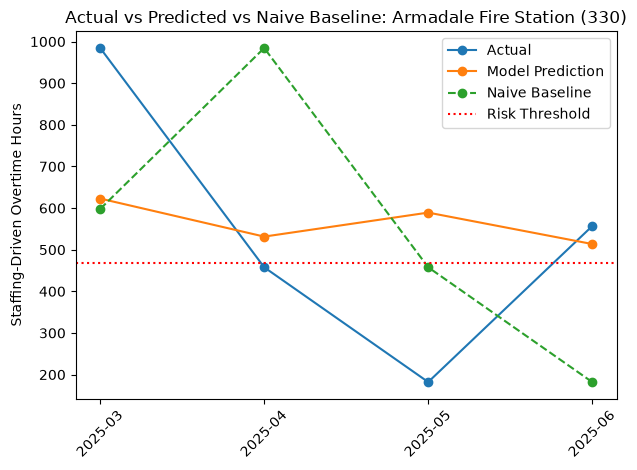

In [40]:
station_to_plot = 'Armadale Fire Station (330)'  # the one flagged True earlier, worth a look
station_data = results[results['Station'] == station_to_plot].sort_values('Month')

plt.plot(station_data['Month'].astype(str), station_data['Actual'], label='Actual', marker='o')
plt.plot(station_data['Month'].astype(str), station_data['Predicted'], label='Model Prediction', marker='o')
plt.plot(station_data['Month'].astype(str), station_data['Naive Baseline'], label='Naive Baseline', marker='o', linestyle='--')
plt.axhline(station_data['Threshold'].iloc[0], color='red', linestyle=':', label='Risk Threshold')
plt.legend()
plt.title(f'Actual vs Predicted vs Naive Baseline: {station_to_plot}')
plt.ylabel('Staffing-Driven Overtime Hours')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Export data to create dashboard in Tableau

In [41]:
export_df = results[['Station', 'Month', 'Actual', 'Predicted', 'Naive Baseline', 'Threshold', 'Risk Flag']].copy()
export_df['Month'] = export_df['Month'].astype(str)
export_df.to_csv('overtime_predictions.csv', index=False)                      

## 8. Conclusion/Limitations & Future Work

- Scoped to station-month grain due to no available roster/establishment table
- Month-of-year is encoded linearly (1–12), not cyclically
- Risk flagging uses a fixed historical percentile threshold
- Othe data sets i.e. Incident Mobilisation and Health & Safety data were not used due to unresolved employee-ID linkage
- Leave Booking data is a natural next addition for predicting sick-leave-driven
  overtime ahead of time